# **<u>Exploratory Data Analysis</u>**

_Author: Anass Anhari_

In this  notebook we are going to:
- Recursively read `*_kurso_ivertinimai.json` of the RTU raw dataset
- Builds a unified `grade_grades` DataFrame
- Computes EDA metrics: unique students, unique courses, total enrollments, ...

## **Database Schema Exploration**

### **Course Table** (`course`)
The `course` table (aliased as `c`) holds information about courses.

| Field | Type | Description |
|-------|------|-------------|
| `id` | Primary Key | Unique course identifier |
| `fullname` | String | Full name of the course |
| `startdate` | Timestamp | Course start date |
| `enddate` | Timestamp | Course end date |

### **Grade Items Table** (`grade_items`)
The `grade_items` table (aliased as `gi`) holds information about individual grade items for courses.

| Field | Type | Description |
|-------|------|-------------|
| `id` | Primary Key | Unique grade item identifier |
| `courseid` | Foreign Key | Links the grade item to a course |
| `itemname` | String | Name of the grade item |
| `itemtype` | String | Type of grade item (assignment, quiz, etc.) |
| `grademax` | Decimal | Maximum possible grade for the item |

### **Grade Grades Table** (`grade_grades`)
The `grade_grades` table (aliased as `gg`) holds the actual grades for users corresponding to the grade items.

| Field | Type | Description |
|-------|------|-------------|
| `itemid` | Foreign Key | Links the grade to a specific grade item |
| `userid` | Foreign Key | ID of the user who received the grade |
| `rawgrade` | Decimal | The raw grade value for the user |
| `finalgrade` | Decimal | The final calculated grade after adjustments |
| `timemodified` | Timestamp | When the grade was last modified |

### **User Table** (`user`)
The `user` table (aliased as `u`) stores information about users.

| Field | Type | Description |
|-------|------|-------------|
| `id` | Primary Key | Unique user identifier |
| `firstname` | String | First name of the user |
| `lastname` | String | Last name of the user |

## **Entity Relationship Diagram**

```mermaid
erDiagram
    course ||--o{ grade_items : "has"
    grade_items ||--o{ grade_grades : "has"
    user ||--o{ grade_grades : "receives"
    
    course {
        int id PK
        string fullname
        timestamp startdate
        timestamp enddate
    }
    
    grade_items {
        int id PK
        int courseid FK
        string itemname
        string itemtype
        decimal grademax
    }
    
    grade_grades {
        int itemid FK
        int userid FK
        decimal rawgrade
        decimal finalgrade
        timestamp timemodified
    }
    
    user {
        int id PK
        string firstname
        string lastname
    }
```

In [1]:
import json
import pandas as pd
from pathlib import Path
from typing import Any
from tqdm import tqdm
import matplotlib.pyplot as plt
from educast.constants import RTU_DATA_DIR, INTERIM_DATA_DIR

In [2]:
grade_files: list[Path] = list(RTU_DATA_DIR.glob("*/*/*_kurso_ivertinimai.json"))
print(f"Found {len(grade_files)} grade files.")

for f in grade_files[:5]:
    print(" -", f.relative_to(RTU_DATA_DIR))

Found 6512 grade files.
 - 21-22-P/144743/144743_kurso_ivertinimai.json
 - 21-22-P/144571/144571_kurso_ivertinimai.json
 - 21-22-P/144929/144929_kurso_ivertinimai.json
 - 21-22-P/157502/157502_kurso_ivertinimai.json
 - 21-22-P/146470/146470_kurso_ivertinimai.json


In [3]:
sample: dict[str, Any] = json.load(Path(RTU_DATA_DIR / "21-22-P" / "144243" / "144243_kurso_ivertinimai.json").open())
print("Sample record:", sample[0])
print("\nSample record keys:", list(sample[0].keys()))
print("\nNumber of records in sample file:", len(sample))

Sample record: {'id': 286103, 'itemid': 286103, 'userid': 212795, 'rawgrade': None, 'rawgrademax': '100.00000', 'rawgrademin': '0.00000', 'rawscaleid': None, 'usermodified': None, 'finalgrade': '0.00000', 'hidden': 0, 'locked': 0, 'locktime': 0, 'exported': 0, 'overridden': 0, 'excluded': 0, 'feedback': None, 'feedbackformat': 0, 'information': None, 'informationformat': 0, 'timecreated': 1630439041, 'timemodified': 1630439041, 'aggregationstatus': 'unknown', 'aggregationweight': None, 'courseid': 144243, 'categoryid': None, 'itemname': None, 'itemtype': 'course', 'itemmodule': None, 'iteminstance': 106788, 'itemnumber': None, 'iteminfo': None, 'idnumber': None, 'calculation': None, 'gradetype': 1, 'grademax': '100.00000', 'grademin': '0.00000', 'scaleid': None, 'outcomeid': None, 'gradepass': '0.00000', 'multfactor': '1.00000', 'plusfactor': '0.00000', 'aggregationcoef': '0.00000', 'sortorder': 1, 'display': 0, 'decimals': None, 'needsupdate': 0, 'aggregationcoef2': '0.00000', 'weight

In [4]:
all_records = []
empty_files = []
bad_files = []

for file in tqdm(grade_files, desc="Loading course grade JSONs"):
    try:
        with open(file, "r", encoding="utf-8") as f:
            data = json.load(f)
            if data:
                term_dir = file.parts[-3]   # e.g. "21-22-P"
                course_id = file.parts[-2]  # e.g. "144243"
                for rec in data:
                    rec["_term"] = term_dir
                    rec["_course_id_dir"] = course_id
                    rec["_source_file"] = str(file.relative_to(RTU_DATA_DIR))
                all_records.extend(data)
            else:
                empty_files.append(str(file.relative_to(RTU_DATA_DIR)))
    except json.JSONDecodeError:
        bad_files.append(str(file.relative_to(RTU_DATA_DIR)))

total = len(grade_files)
empty = len(empty_files)
bad = len(bad_files)
non_empty = total - empty - bad

print(f"Total files: {total}")
print(f"Loaded {len(all_records):,} valid records.")
print(f"Empty files: {empty}, Bad JSONs: {bad}, Non-empty: {non_empty}")

Loading course grade JSONs: 100%|██████████| 6512/6512 [00:54<00:00, 118.69it/s]

Total files: 6512
Loaded 1,533,649 valid records.
Empty files: 3896, Bad JSONs: 0, Non-empty: 2616


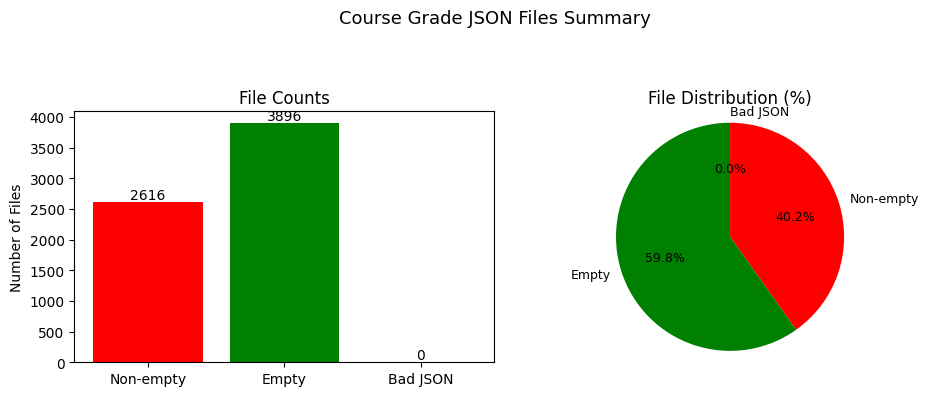

In [5]:
counts = [non_empty, empty, bad]
labels = ["Non-empty", "Empty", "Bad JSON"]
colors = ["red", "green", "blue"]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(labels, counts, color=colors)
axes[0].set_title("File Counts")
axes[0].set_ylabel("Number of Files")
for i, val in enumerate(counts):
    axes[0].text(i, val, str(val), ha="center", va="bottom", fontsize=10)

axes[1].pie(
    counts,
    labels=labels,
    colors=colors,
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False,
    textprops={"fontsize": 9},
)
axes[1].set_title("File Distribution (%)")
axes[1].axis("equal")

fig.suptitle("Course Grade JSON Files Summary", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

In [6]:
df = pd.DataFrame(all_records)
print("Initial DataFrame shape:", df.shape)

Initial DataFrame shape: (1533649, 51)


In [7]:
df.head()

,id,itemid,userid,rawgrade,rawgrademax,rawgrademin,rawscaleid,usermodified,finalgrade,hidden,...,aggregationcoef,sortorder,display,decimals,needsupdate,aggregationcoef2,weightoverride,_term,_course_id_dir,_source_file
0,526288,526288,165852,None,10.00000,0.00000,NaN,165852.0,None,0,...,1.00000,5,0,NaN,0,0.00000,0,21-22-P,144743,21-22-P/144743/144743_kurso_ivertinimai.json
1,426388,426388,165852,None,10.00000,0.00000,NaN,NaN,0.00000,0,...,0.00000,1,0,NaN,0,0.00000,0,21-22-P,144743,21-22-P/144743/144743_kurso_ivertinimai.json
2,526255,526255,165852,None,10.00000,0.00000,NaN,NaN,None,0,...,1.00000,2,0,NaN,0,0.00000,0,21-22-P,144743,21-22-P/144743/144743_kurso_ivertinimai.json
3,526268,526268,165852,None,10.00000,0.00000,NaN,NaN,None,0,...,1.00000,3,0,NaN,0,0.00000,0,21-22-P,144743,21-22-P/144743/144743_kurso_ivertinimai.json
4,526287,526287,165852,None,10.00000,0.00000,NaN,NaN,None,0,...,1.00000,4,0,NaN,0,0.00000,0,21-22-P,144743,21-22-P/144743/144743_kurso_ivertinimai.json


In [8]:
df.dtypes

id                     int64
itemid                 int64
userid                 int64
rawgrade              object
rawgrademax           object
rawgrademin           object
rawscaleid           float64
usermodified         float64
finalgrade            object
hidden                 int64
locked                 int64
locktime               int64
exported               int64
overridden             int64
excluded               int64
feedback              object
feedbackformat         int64
information           object
informationformat      int64
timecreated            int64
timemodified           int64
aggregationstatus     object
aggregationweight     object
courseid               int64
categoryid           float64
itemname              object
itemtype              object
itemmodule            object
iteminstance         float64
itemnumber           float64
iteminfo              object
idnumber              object
calculation           object
gradetype              int64
grademax      

In [9]:
header = [
    "# Raw data comlumn summary\n",
    f"**Generated:** {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}\n",
    f"**Total Rows:** {len(df):,}\n",
    "---\n"
]

# Two separate lists (the public one and the private one showing sample values)
md_private = header.copy()
md_public = header.copy()

for col in df.columns:
    if df[col].dtype == 'object':
        unique_vals = df[col].unique()
        n_unique = len(unique_vals)
        display_vals = unique_vals[:20]

        # Shared info
        info = [
            f"\n## Column: `{col}`\n",
            f"- **Type:** `{df[col].dtype}`\n",
            f"- **Unique values:** {n_unique:,}\n",
        ]

        md_private.extend(info)
        md_public.extend(info)

        # Private info (we could potentially leak info such as feedback, personal information ,....)
        md_private.append("- **Sample values (up to 20):**\n")
        for val in display_vals:
            val_str = str(val)
            if len(val_str) > 200:
                val_str = val_str[:200] + "..."
            val_str = val_str.replace("|", "\\|").replace("\n", " ")
            md_private.append(f"  - `{val_str}`\n")

        if n_unique > 20:
            md_private.append(f"\n  *... and {n_unique - 20:,} more unique values*\n")


        md_public.append("- **Sample values:** _hidden for privacy_\n")

public_path = INTERIM_DATA_DIR / "raw_data_column_summary.md"
private_path = INTERIM_DATA_DIR / "raw_data_column_summary_private.md"

with open(private_path, "w", encoding="utf-8") as f:
    f.writelines(md_private)

with open(public_path, "w", encoding="utf-8") as f:
    f.writelines(md_public)

In [10]:
# Columns that should be numeric but are currently 'object' type
numeric_cols = [
    'rawgrade', 
    'rawgrademax', 
    'rawgrademin', 
    'finalgrade',
    'aggregationweight',
    'grademax',
    'grademin',
    'gradepass',
    'multfactor',
    'plusfactor',
    'aggregationcoef',
    'aggregationcoef2'
]

# Columns that should stay as strings
str_cols = [
    'feedback',
    'information',
    'aggregationstatus',
    'itemname',
    'itemtype',
    'itemmodule',
    'iteminfo',
    'idnumber',
    'calculation',
    'outcomeid',
    '_term',
    '_course_id_dir',
    '_source_file'
]

In [11]:
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

for col in str_cols:
    if col in df.columns:
        df[col] = df[col].astype("string")

time_cols = ["timecreated", "timemodified"]
for col in time_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], unit="s", errors="coerce")

print("DataFrame shape:", df.shape)
df.head()

DataFrame shape: (1533649, 51)


,id,itemid,userid,rawgrade,rawgrademax,rawgrademin,rawscaleid,usermodified,finalgrade,hidden,...,aggregationcoef,sortorder,display,decimals,needsupdate,aggregationcoef2,weightoverride,_term,_course_id_dir,_source_file
0,526288,526288,165852,NaN,10.0,0.0,NaN,165852.0,NaN,0,...,1.0,5,0,NaN,0,0.0,0,21-22-P,144743,21-22-P/144743/144743_kurso_ivertinimai.json
1,426388,426388,165852,NaN,10.0,0.0,NaN,NaN,0.0,0,...,0.0,1,0,NaN,0,0.0,0,21-22-P,144743,21-22-P/144743/144743_kurso_ivertinimai.json
2,526255,526255,165852,NaN,10.0,0.0,NaN,NaN,NaN,0,...,1.0,2,0,NaN,0,0.0,0,21-22-P,144743,21-22-P/144743/144743_kurso_ivertinimai.json
3,526268,526268,165852,NaN,10.0,0.0,NaN,NaN,NaN,0,...,1.0,3,0,NaN,0,0.0,0,21-22-P,144743,21-22-P/144743/144743_kurso_ivertinimai.json
4,526287,526287,165852,NaN,10.0,0.0,NaN,NaN,NaN,0,...,1.0,4,0,NaN,0,0.0,0,21-22-P,144743,21-22-P/144743/144743_kurso_ivertinimai.json


In [12]:
df.dtypes

id                            int64
itemid                        int64
userid                        int64
rawgrade                    float64
rawgrademax                 float64
rawgrademin                 float64
rawscaleid                  float64
usermodified                float64
finalgrade                  float64
hidden                        int64
locked                        int64
locktime                      int64
exported                      int64
overridden                    int64
excluded                      int64
feedback             string[python]
feedbackformat                int64
information          string[python]
informationformat             int64
timecreated          datetime64[ns]
timemodified         datetime64[ns]
aggregationstatus    string[python]
aggregationweight           float64
courseid                      int64
categoryid                  float64
itemname             string[python]
itemtype             string[python]
itemmodule           string[

Now lets compute some metrics such as unique students and the enrollments attempts subsetting the dataframe by user, course and final grade as retakes can be taken and are allowed

In [14]:
# Include finalgrade to count total enrollment attempts (including retakes)
subset_cols = ["userid", "courseid", "finalgrade"]
enrollments = (
    df.dropna(subset=subset_cols)
      .loc[:, subset_cols]
      .drop_duplicates()
)

# Unique course enrollments (ignore finalgrade to avoid counting retakes)
unique_enrollments = enrollments.drop(columns="finalgrade").drop_duplicates()

metrics = {}
metrics["total_enrollments"] = len(enrollments)         # all attempts
metrics["unique_enrollments"] = len(unique_enrollments) # without retakes
metrics

{'total_enrollments': 377560, 'unique_enrollments': 87850}

In [15]:
enrollments

,userid,courseid,finalgrade
1,165852,144743,0.00000
7,212799,144743,0.00000
12,212268,144743,0.00000
18,224350,157502,9.00000
19,224350,157502,7.25000
...,...,...,...
1533635,169927,141844,31.66667
1533636,169927,141844,75.00000
1533637,146597,141844,23.00000
1533638,146597,141844,7.66667


In [16]:
SAVE_INTERIM_DATA: bool = False
if SAVE_INTERIM_DATA:
    df[:10].to_csv(INTERIM_DATA_DIR / "flattened_grades_private.csv", index=False)

In [17]:
if SAVE_INTERIM_DATA:
    df.to_csv(INTERIM_DATA_DIR / "flattened_grades_private.csv", index=False)

In [ ]:
unique_eventnames = set()
unique_targets = set()
unique_actions = set()

kurso_activity_logas_files = list(RTU_DATA_DIR.glob("*/*/*_kurso_activity_logas.json"))
print(f"Found {len(kurso_activity_logas_files)} kurso_activity_logas.json files.")

for file in tqdm(kurso_activity_logas_files, desc="Processing kurso_activity_logas.json files"):
    with open(file, encoding="utf-8") as f:
        try:
            data = json.load(f)
        except json.JSONDecodeError:
            print(f"Skipping invalid JSON: {file}")
            continue

    for record in data:
        unique_eventnames.add(record.get("eventname"))
        unique_targets.add(record.get("target"))
        unique_actions.add(record.get("action"))

unique_eventnames = sorted([e for e in unique_eventnames if e is not None])
unique_targets = sorted([t for t in unique_targets if t is not None])
unique_actions = sorted([a for a in unique_actions if a is not None])

output_dir = INTERIM_DATA_DIR / "kurso_activity_logas" / "clickstream_unique_values"
output_dir.mkdir(parents=True, exist_ok=True)

with open(output_dir / "unique_eventnames.md", "w", encoding="utf-8") as f:
    for eventname in unique_eventnames:
        f.write(eventname + "\n")

with open(output_dir / "unique_targets.md", "w", encoding="utf-8") as f:
    for target in unique_targets:
        f.write(target + "\n")

with open(output_dir / "unique_actions.md", "w", encoding="utf-8") as f:
    for action in unique_actions:
        f.write(action + "\n")

# NOTE: https://docs.moodle.org/dev/Events_API lists all standard event names, targets, and actions

In [ ]:
OUTPUT_DIR = Path("interim_data/kurso_activity_logas")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

unique_triples = set()

kurso_activity_logas_files = list(RTU_DATA_DIR.glob("*/*/*_kurso_activity_logas.json"))
print(f"Found {len(kurso_activity_logas_files)} kurso_activity_logas.json files.")

for file in tqdm(kurso_activity_logas_files, desc="Processing activity logs"):
    with open(file, encoding="utf-8") as f:
        try:
            data = json.load(f)
        except json.JSONDecodeError:
            print(f"Skipping invalid JSON: {file}")
            continue

    for record in data:
        target = record.get("target") or ""
        event = record.get("eventname") or ""
        action = record.get("action") or ""
        unique_triples.add((target, event, action))

summary = [
    {"target": t, "event": e, "action": a}
    for t, e, a in sorted(unique_triples)
]

with open(OUTPUT_DIR / "activity_log_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print(f"Saved activity log summary to {OUTPUT_DIR / 'activity_log_summary.json'}")
print(f"Found {len(summary)} unique (target, event, action) combinations.")